## 1. Data Preprocessing & Feature Engineering

In [1]:
import numpy as np
import pandas as pd

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")

dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

print(f"X: {X.shape}\n", X)
print(100*'=')
print(f"y: {y.shape}\n", y)

X: (10000, 10)
 [[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]
y: (10000,)
 [1 0 1 ... 1 1 0]


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

print(f"X: {X.shape}\n", X)

X: (10000, 10)
 [[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

print(f"X: {X.shape}\n", X)

X: (10000, 12)
 [[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2. Multi-Layer Perceptron (MLP) Architecture Definition

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()

        self.out = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.sigmoid(self.out(x))
        return x

    def predict(self, x_numpy):
        self.eval() # Switch to evaluation mode
        with torch.no_grad():
            # Convert input data to a PyTorch float tensor
            x_tensor = torch.tensor(x_numpy, dtype=torch.float32)
            # Get predictions out of the network
            probabilities = self(x_tensor)
            # Convert result back to a NumPy array
            return probabilities.numpy()

In [9]:
ann = MLPClassifier(input_dim=X_train.shape[1])

## 3. PyTorch Data Loaders & Batching Configuration

In [10]:
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

# Combine into a dataset and create a batch loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

## 4. Loss Function & Adaptive Optimizer (Adam) Setup

In [11]:
criterion = nn.BCELoss()
optimizer = optim.Adam(ann.parameters(), lr=0.01)

## 5. Network Training Loop (Forward & Backward Passes)

In [12]:
epochs = 100  # Total passes over the entire dataset
loss_history = []

ann.train()  # Explicitly set the model to training mode
for epoch in range(epochs):
    running_loss = 0.0
    
    # Loop over mini-batches of data
    for batch_X, batch_y in train_loader:
        # Step A: Clear previous gradient states
        optimizer.zero_grad()
        
        # Step B: Forward pass to get model probabilities
        predictions = ann(batch_X)
        
        # Step C: Calculate error against true labels
        loss = criterion(predictions, batch_y)
        
        # Step D: Backward pass to calculate parameter gradients
        loss.backward()
        
        # Step E: Update network weights
        optimizer.step()
        
        # Track training statistics
        running_loss += loss.item() * batch_X.size(0)
        
    # Calculate average loss over the whole epoch dataset
    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}")

print("Training finished successfully!")

Epoch [1/100] - Loss: 0.4221
Epoch [10/100] - Loss: 0.3406
Epoch [20/100] - Loss: 0.3328
Epoch [30/100] - Loss: 0.3270
Epoch [40/100] - Loss: 0.3233
Epoch [50/100] - Loss: 0.3198
Epoch [60/100] - Loss: 0.3169
Epoch [70/100] - Loss: 0.3158
Epoch [80/100] - Loss: 0.3145
Epoch [90/100] - Loss: 0.3150
Epoch [100/100] - Loss: 0.3129
Training finished successfully!


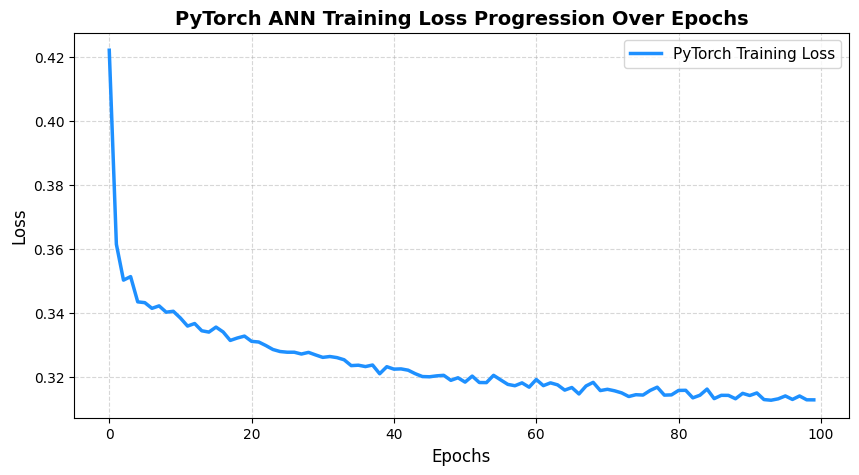

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, color='dodgerblue', linewidth=2.5, label='PyTorch Training Loss')
plt.title('PyTorch ANN Training Loss Progression Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

## 6. Model Evaluation & Confusion Matrix Analysis

In [14]:
print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

[[False]]


In [15]:
# Get probabilities, binarize them, and align shapes for side-by-side print
y_preds = ann.predict(X_test)
y_preds = (y_preds > 0.5)

# Ensure shapes match for concatenation
print(np.concatenate((y_preds.reshape(len(y_preds),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 ...
 [1 1]
 [0 1]
 [0 1]]


In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
print("--- Evaluation Results ---")
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_preds)
print(f"Accuracy Score: {acc * 100:.2f}%")

--- Evaluation Results ---
Confusion Matrix:
 [[1525   82]
 [ 198  195]]
Accuracy Score: 86.00%
